# Annotator Results Summary

This notebook summarises the human-annotator evaluation of the candidate clustering taxonomies.

Each annotator scored the **same 16 clustering trials** (drawn from 4 sources: `gpt5_nano`, `apertus`, `data_points`, `phi4_mini`).
For every trial they rated each topic on two axes:

- **cohesion** (0–100) — how internally consistent the topic is
- **fit** (1–5) — how well the topic fits the intended taxonomy

and the app stored per-trial aggregates (`cohesion_mean`, `fit_mean`, `overall`).

Files used per annotator folder:

| file | meaning |
|------|---------|
| `evaluation_submitted.json` | final submitted ratings (core data) |
| `evaluation_order.json` | order trials were shown in |
| `evaluation_timer.json` | time spent on the evaluation task |
| `moderation_timer.json` | time spent on the moderation task |
| `top_trials.json` | trial metadata (dbcv, ccc, cluster count) — identical across annotators |
| `moderated_taxonomy.json` / `placed_keys.json` | output of the (optional) moderation step |

In [2]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Base directory = folder containing this notebook (with a sensible fallback).
try:
    BASE = Path(__file__).resolve().parent  # noqa: F821
except NameError:
    BASE = Path.cwd()
if not sorted(BASE.glob("annotator*/evaluation_submitted.json")):
    # fallback when launched from a parent dir
    cand = BASE / "annotator_results"
    if cand.exists():
        BASE = cand

ANNOTATOR_DIRS = sorted(p for p in BASE.glob("annotator*") if p.is_dir())
print("Base directory:", BASE)
print("Annotators found:", [p.name for p in ANNOTATOR_DIRS])

Base directory: c:\Users\svangelova\Code Projects\Computational Taxonomy Development\taxonomy_web_interface\annotator_results
Annotators found: ['annotator 1', 'annotator 2', 'annotator 3']


## 1. Load the data

We build a **tidy long table** — one row per (annotator, source, trial, topic) — plus a per-trial aggregate table from the values the app already computed.

In [3]:
def load_json(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)


topic_rows = []     # one row per rated topic
trial_rows = []     # one row per rated trial (app aggregates)
meta_rows = []      # annotator-level metadata (time, counts)

for adir in ANNOTATOR_DIRS:
    name = adir.name
    submitted = load_json(adir / "evaluation_submitted.json")
    ratings = submitted.get("ratings", {})

    for key, rec in ratings.items():
        source, trial = key.split(":")
        trial = int(trial)
        trial_rows.append({
            "annotator": name,
            "source": source,
            "trial": trial,
            "n_topics": len(rec.get("topics", {})),
            "cohesion_mean": rec.get("cohesion_mean"),
            "fit_mean": rec.get("fit_mean"),
            "overall": rec.get("overall"),
        })
        for topic_id, scores in rec.get("topics", {}).items():
            topic_rows.append({
                "annotator": name,
                "source": source,
                "trial": trial,
                "topic": int(topic_id),
                "cohesion": scores.get("cohesion"),
                "fit": scores.get("fit"),
            })

    # timers (seconds -> minutes)
    eval_t = load_json(adir / "evaluation_timer.json").get("elapsed_seconds") if (adir / "evaluation_timer.json").exists() else None
    mod_path = adir / "moderation_timer.json"
    mod_t = load_json(mod_path).get("elapsed_seconds") if mod_path.exists() else None
    has_moderation = (adir / "moderated_taxonomy.json").exists()
    meta_rows.append({
        "annotator": name,
        "submitted_at": submitted.get("submitted_at"),
        "n_trials_rated": len(ratings),
        "eval_minutes": (eval_t / 60) if eval_t else None,
        "moderation_minutes": (mod_t / 60) if mod_t else None,
        "did_moderation": has_moderation,
    })

topics_df = pd.DataFrame(topic_rows)
trials_df = pd.DataFrame(trial_rows)
meta_df = pd.DataFrame(meta_rows)

print(f"{len(topics_df):,} topic ratings | {len(trials_df):,} trial ratings | {len(meta_df)} annotators")
topics_df.head()

861 topic ratings | 48 trial ratings | 3 annotators


,annotator,source,trial,topic,cohesion,fit
0,annotator 1,gpt5_nano,94,19,90,4
1,annotator 1,gpt5_nano,94,18,50,4
2,annotator 1,gpt5_nano,94,4,70,4
3,annotator 1,gpt5_nano,94,9,90,5
4,annotator 1,gpt5_nano,94,11,90,5


In [4]:
# Attach trial metadata (dbcv / ccc / cluster count) from top_trials.json.
# This file is shared across annotators, so load it once from any annotator that has it.
trial_meta = {}
source_labels = {}
for adir in ANNOTATOR_DIRS:
    tt_path = adir / "top_trials.json"
    if tt_path.exists():
        for t in load_json(tt_path):
            trial_meta[(t["source"], t["trial"])] = {
                "source_label": t.get("source_label"),
                "dbcv": t.get("dbcv"),
                "ccc": t.get("ccc"),
                "metric_avg": t.get("avg"),
                "n_clusters": t.get("meta", {}).get("clusters"),
                "outlier_ratio": t.get("meta", {}).get("outlier_ratio"),
            }
            source_labels[t["source"]] = t.get("source_label")
        break

meta_lookup = pd.DataFrame([{"source": s, "trial": tr, **v} for (s, tr), v in trial_meta.items()])
trials_df = trials_df.merge(meta_lookup, on=["source", "trial"], how="left")
topics_df["source_label"] = topics_df["source"].map(source_labels)
trials_df["trial_id"] = trials_df["source"] + ":" + trials_df["trial"].astype(str)
trials_df.head()

,annotator,source,trial,n_topics,cohesion_mean,fit_mean,overall,source_label,dbcv,ccc,metric_avg,n_clusters,outlier_ratio,trial_id
0,annotator 1,gpt5_nano,94,20,68.00,4.10,75.00,GPT5-nano,0.52,0.61,0.56,20,0.23,gpt5_nano:94
1,annotator 1,apertus,151,34,74.71,3.09,68.24,Apertus-8B-Instruct,0.64,0.60,0.62,34,0.41,apertus:151
2,annotator 1,data_points,204,18,78.89,3.89,78.33,data point names,0.53,0.69,0.61,18,0.40,data_points:204
3,annotator 1,data_points,254,19,79.47,4.32,82.89,data point names,0.55,0.66,0.60,20,0.42,data_points:254
4,annotator 1,data_points,218,14,67.14,3.71,70.71,data point names,0.53,0.71,0.62,14,0.48,data_points:218


## 2. Annotator overview

How many trials each annotator rated, time spent, and whether they completed the moderation step.

In [5]:
meta_df

,annotator,submitted_at,n_trials_rated,eval_minutes,moderation_minutes,did_moderation
0,annotator 1,2026-05-30T19:31:26.392457+00:00,16,113.14,48.28,True
1,annotator 2,2026-06-01T11:51:38.871163+00:00,16,114.19,NaN,True
2,annotator 3,2026-06-01T13:33:34.069161+00:00,16,276.81,NaN,False


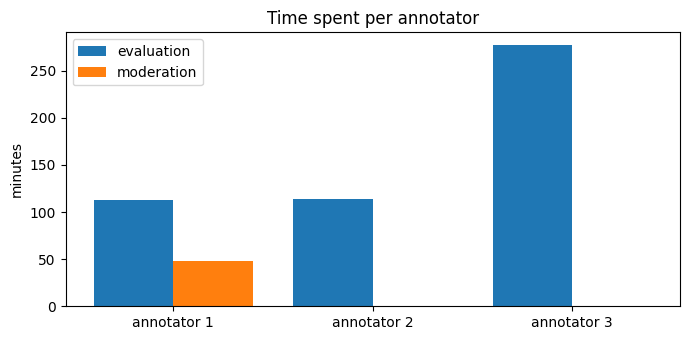

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(meta_df))
w = 0.4
ax.bar(x - w / 2, meta_df["eval_minutes"].fillna(0), w, label="evaluation")
ax.bar(x + w / 2, meta_df["moderation_minutes"].fillna(0), w, label="moderation")
ax.set_xticks(x)
ax.set_xticklabels(meta_df["annotator"])
ax.set_ylabel("minutes")
ax.set_title("Time spent per annotator")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Per-trial scores

The `overall` score (0–100) is the app's headline rating for each trial. Below we average it across annotators and rank the trials.

In [7]:
trial_summary = (
    trials_df
    .groupby(["source", "trial"])
    .agg(
        source_label=("source_label", "first"),
        n_clusters=("n_clusters", "first"),
        dbcv=("dbcv", "first"),
        ccc=("ccc", "first"),
        overall_mean=("overall", "mean"),
        overall_std=("overall", "std"),
        cohesion_mean=("cohesion_mean", "mean"),
        fit_mean=("fit_mean", "mean"),
        n_annotators=("annotator", "nunique"),
    )
    .reset_index()
    .sort_values("overall_mean", ascending=False)
)
trial_summary

,source,trial,source_label,n_clusters,dbcv,ccc,overall_mean,overall_std,cohesion_mean,fit_mean,n_annotators
4,data_points,191,data point names,22,0.56,0.64,78.03,8.91,68.18,4.39,3
11,gpt5_nano,233,GPT5-nano,36,0.56,0.60,77.13,9.32,71.85,4.12,3
8,gpt5_nano,42,GPT5-nano,20,0.57,0.61,76.83,11.07,67.33,4.32,3
7,data_points,254,data point names,20,0.55,0.66,75.00,7.24,71.05,3.95,3
5,data_points,204,data point names,18,0.53,0.69,74.81,5.16,67.78,4.09,3
9,gpt5_nano,94,GPT5-nano,20,0.52,0.61,72.67,3.62,58.67,4.33,3
6,data_points,218,data point names,14,0.53,0.71,72.14,2.47,62.38,4.10,3
10,gpt5_nano,203,GPT5-nano,15,0.53,0.60,71.89,12.37,53.56,4.51,3
0,apertus,151,Apertus-8B-Instruct,34,0.64,0.60,69.61,3.17,68.82,3.52,3
2,apertus,281,Apertus-8B-Instruct,13,0.52,0.69,65.77,17.01,58.72,3.64,3


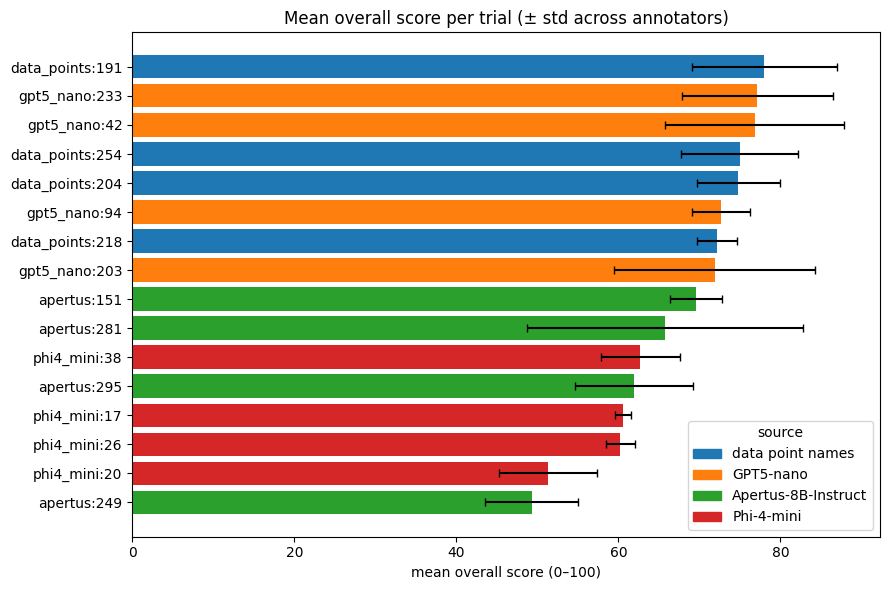

In [8]:
# Ranked bar chart of mean overall score per trial, coloured by source.
ts = trial_summary.copy()
ts["label"] = ts["source"] + ":" + ts["trial"].astype(str)
sources = ts["source"].unique()
cmap = {s: c for s, c in zip(sources, plt.cm.tab10.colors)}

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(ts))[::-1]
ax.barh(y, ts["overall_mean"], xerr=ts["overall_std"].fillna(0),
        color=[cmap[s] for s in ts["source"]], capsize=3)
ax.set_yticks(y)
ax.set_yticklabels(ts["label"])
ax.set_xlabel("mean overall score (0–100)")
ax.set_title("Mean overall score per trial (± std across annotators)")
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[s]) for s in sources]
ax.legend(handles, [source_labels.get(s, s) for s in sources], title="source", loc="lower right")
plt.tight_layout()
plt.show()

## 4. Per-source (model family) comparison

Aggregating trials by their source model family.

In [9]:
source_summary = (
    trials_df
    .groupby("source")
    .agg(
        source_label=("source_label", "first"),
        n_trials=("trial", "nunique"),
        overall_mean=("overall", "mean"),
        cohesion_mean=("cohesion_mean", "mean"),
        fit_mean=("fit_mean", "mean"),
    )
    .reset_index()
    .sort_values("overall_mean", ascending=False)
)
source_summary

,source,source_label,n_trials,overall_mean,cohesion_mean,fit_mean
1,data_points,data point names,4,75.00,67.35,4.13
2,gpt5_nano,GPT5-nano,4,74.63,62.85,4.32
0,apertus,Apertus-8B-Instruct,4,61.65,59.39,3.20
3,phi4_mini,Phi-4-mini,4,58.72,47.67,3.49


C:\Users\svangelova\AppData\Local\Temp\ipykernel_35628\2597716308.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=labels)


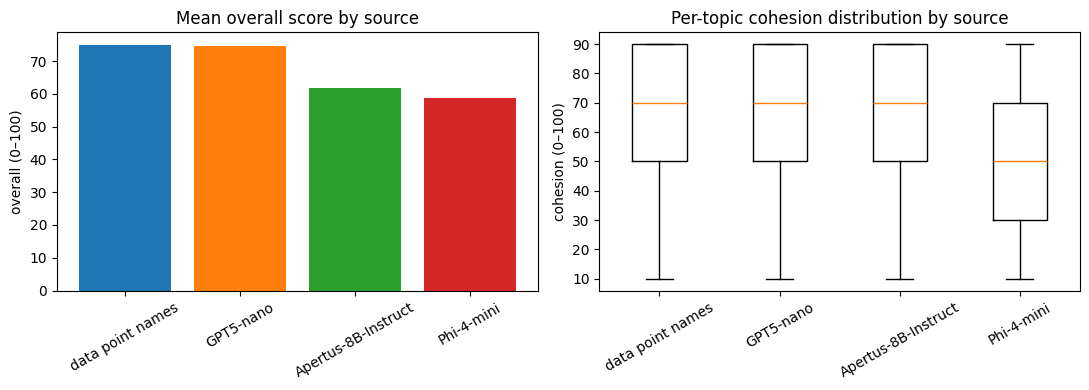

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = source_summary["source"]
labels = source_summary["source_label"].fillna(source_summary["source"])

axes[0].bar(labels, source_summary["overall_mean"], color=[cmap[s] for s in order])
axes[0].set_title("Mean overall score by source")
axes[0].set_ylabel("overall (0–100)")
axes[0].tick_params(axis="x", rotation=30)

# distribution of per-topic scores by source
data = [topics_df.loc[topics_df["source"] == s, "cohesion"].dropna() for s in order]
axes[1].boxplot(data, labels=labels)
axes[1].set_title("Per-topic cohesion distribution by source")
axes[1].set_ylabel("cohesion (0–100)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 5. Human scores vs. automatic clustering metrics

Do the annotators' `overall` scores agree with the automatic clustering quality metrics (DBCV, CCC) that were used to select these trials?

In [11]:
trial_summary.cohesion_mean

4    68.18
11   71.85
8    67.33
7    71.05
5    67.78
9    58.67
6    62.38
10   53.56
0    68.82
2    58.72
15   50.83
3    60.00
12   47.22
14   49.30
13   43.33
1    50.00
Name: cohesion_mean, dtype: float64

Pearson correlation with mean overall score:
  DBCV       : +0.511
  CCC        : -0.539
  n_clusters : +0.699


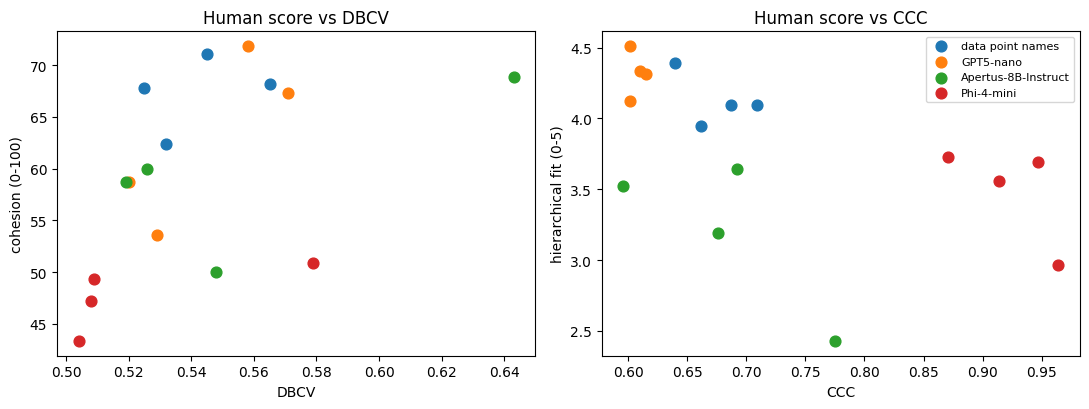

In [13]:
corr_df = trial_summary.dropna(subset=["dbcv", "ccc", "cohesion_mean", "fit_mean"])
if len(corr_df) >= 3:
    print("Pearson correlation with mean overall score:")
    print(f"  DBCV       : {corr_df['dbcv'].corr(corr_df['cohesion_mean']):+.3f}")
    print(f"  CCC        : {corr_df['fit_mean'].corr(corr_df['ccc']):+.3f}")
    print(f"  n_clusters : {corr_df['cohesion_mean'].corr(corr_df['n_clusters']):+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, metric in zip(axes, ["dbcv", "ccc"]):
    for s in sources:
        if metric == "dbcv":
            sub = corr_df[corr_df["source"] == s]
            ax.scatter(sub[metric], sub["cohesion_mean"], color=cmap[s],
                    label=source_labels.get(s, s), s=60)
            ax.set_ylabel("cohesion (0-100)")
            
        else:
            sub = corr_df[corr_df["source"] == s]
            ax.scatter(sub[metric], sub["fit_mean"], color=cmap[s],
                    label=source_labels.get(s, s), s=60)
            ax.set_ylabel("hierarchical fit (0-5)")
    ax.set_xlabel(metric.upper())
    ax.set_title(f"Human score vs {metric.upper()}")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Correlation statistics

Full correlation report (ported from `corr_analysis.py`) between the annotators' perceived scores and the automatic clustering metrics, computed on the per-trial aggregates in `trial_summary`:

- **Pearson r** with a Fisher-z 95% confidence interval, plus **Spearman ρ** as a rank-based check
- reported for **all 16 trials** and **excluding `phi4_mini`** (its trials collapse into one degenerate dense cluster, which inflates CCC)

In [14]:
from scipy import stats


def corr_report(df, x, y, xname, yname, subset="all sources"):
    """Pearson r (with Fisher-z 95% CI) and Spearman rho for one variable pair."""
    d = df.dropna(subset=[x, y])
    n = len(d)
    r, p = stats.pearsonr(d[x], d[y])
    rho, prho = stats.spearmanr(d[x], d[y])
    if n > 3:
        z = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        ci_lo, ci_hi = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)
    else:
        ci_lo = ci_hi = float("nan")
    print(f"[{subset}] {xname}  vs  {yname}   (n={n})")
    print(f"  Pearson  r = {r:+.3f}   R^2 = {r**2:.3f}   p = {p:.4f}   95%CI [{ci_lo:+.2f}, {ci_hi:+.2f}]")
    print(f"  Spearman rho = {rho:+.3f}   p = {prho:.4f}\n")
    return {"subset": subset, "x": xname, "y": yname, "n": n,
            "pearson_r": r, "R2": r**2, "p_pearson": p,
            "ci95_lo": ci_lo, "ci95_hi": ci_hi,
            "spearman_rho": rho, "p_spearman": prho}


CORR_PAIRS = [
    ("cohesion_mean", "dbcv", "perceived cohesion", "DBCV"),
    ("fit_mean", "ccc", "perceived fit", "CCC"),
    ("cohesion_mean", "ccc", "perceived cohesion", "CCC"),
    ("fit_mean", "dbcv", "perceived fit", "DBCV"),
]

no_phi = trial_summary[trial_summary["source"] != "phi4_mini"]

corr_results = pd.DataFrame(
    [corr_report(trial_summary, *pair) for pair in CORR_PAIRS]
    + [corr_report(no_phi, *pair, subset="excl. phi4_mini") for pair in CORR_PAIRS[:2]]
)
corr_results

[all sources] perceived cohesion  vs  DBCV   (n=16)
  Pearson  r = +0.511   R^2 = 0.262   p = 0.0429   95%CI [+0.02, +0.80]
  Spearman rho = +0.606   p = 0.0129

[all sources] perceived fit  vs  CCC   (n=16)
  Pearson  r = -0.539   R^2 = 0.290   p = 0.0313   95%CI [-0.82, -0.06]
  Spearman rho = -0.559   p = 0.0243

[all sources] perceived cohesion  vs  CCC   (n=16)
  Pearson  r = -0.815   R^2 = 0.664   p = 0.0001   95%CI [-0.93, -0.54]
  Spearman rho = -0.736   p = 0.0012

[all sources] perceived fit  vs  DBCV   (n=16)
  Pearson  r = +0.076   R^2 = 0.006   p = 0.7806   95%CI [-0.44, +0.55]
  Spearman rho = +0.244   p = 0.3622

[excl. phi4_mini] perceived cohesion  vs  DBCV   (n=12)
  Pearson  r = +0.444   R^2 = 0.197   p = 0.1486   95%CI [-0.17, +0.81]
  Spearman rho = +0.510   p = 0.0899

[excl. phi4_mini] perceived fit  vs  CCC   (n=12)
  Pearson  r = -0.686   R^2 = 0.471   p = 0.0138   95%CI [-0.90, -0.18]
  Spearman rho = -0.483   p = 0.1114



,subset,x,y,n,pearson_r,R2,p_pearson,ci95_lo,ci95_hi,spearman_rho,p_spearman
0,all sources,perceived cohesion,DBCV,16,0.51,0.26,0.04,0.02,0.80,0.61,0.01
1,all sources,perceived fit,CCC,16,-0.54,0.29,0.03,-0.82,-0.06,-0.56,0.02
2,all sources,perceived cohesion,CCC,16,-0.81,0.66,0.00,-0.93,-0.54,-0.74,0.00
3,all sources,perceived fit,DBCV,16,0.08,0.01,0.78,-0.44,0.55,0.24,0.36
4,excl. phi4_mini,perceived cohesion,DBCV,12,0.44,0.20,0.15,-0.17,0.81,0.51,0.09
5,excl. phi4_mini,perceived fit,CCC,12,-0.69,0.47,0.01,-0.90,-0.18,-0.48,0.11


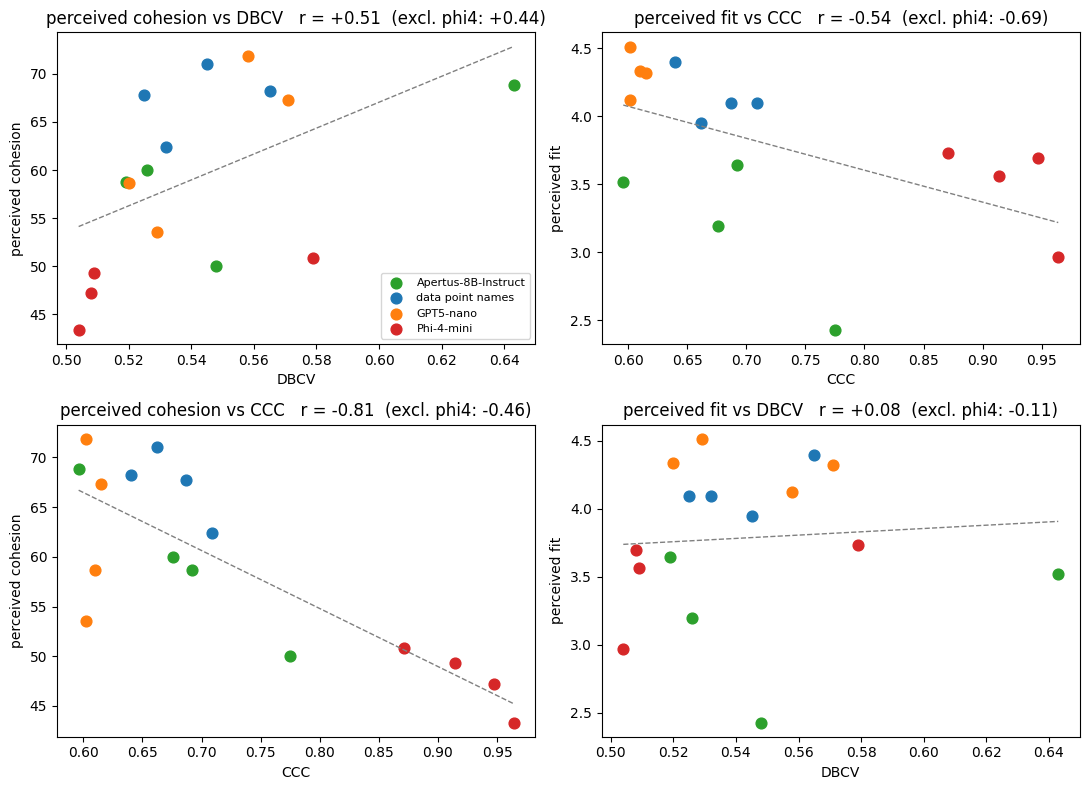

In [15]:
# Scatter plots for each human-score / metric pair, with a least-squares
# fit line and the Pearson r in the title (all sources vs. excl. phi4_mini).
src_colors = {s: c for s, c in zip(trial_summary["source"].unique(), plt.cm.tab10.colors)}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (x, metric, xname, mname) in zip(axes.ravel(), CORR_PAIRS):
    d = trial_summary.dropna(subset=[x, metric])
    for s, sub in d.groupby("source"):
        ax.scatter(sub[metric], sub[x], color=src_colors[s], s=60,
                   label=source_labels.get(s, s))

    slope, intercept = np.polyfit(d[metric], d[x], 1)
    xs = np.linspace(d[metric].min(), d[metric].max(), 50)
    ax.plot(xs, slope * xs + intercept, "--", color="grey", lw=1)

    r_all, _ = stats.pearsonr(d[metric], d[x])
    d_np = d[d["source"] != "phi4_mini"]
    r_np, _ = stats.pearsonr(d_np[metric], d_np[x])
    ax.set_title(f"{xname} vs {mname}   r = {r_all:+.2f}  (excl. phi4: {r_np:+.2f})")
    ax.set_xlabel(mname)
    ax.set_ylabel(xname)

axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Inter-annotator agreement

How consistently did the annotators score the same trials? We pivot the per-trial `overall` score so each column is an annotator, then look at pairwise correlation and per-trial spread.

Pairwise correlation of 'overall' score across annotators:


annotator,annotator 1,annotator 2,annotator 3
annotator,,,
annotator 1,1.00,0.49,0.68
annotator 2,0.49,1.00,0.83
annotator 3,0.68,0.83,1.00


Mean per-trial std across annotators: 6.7 points


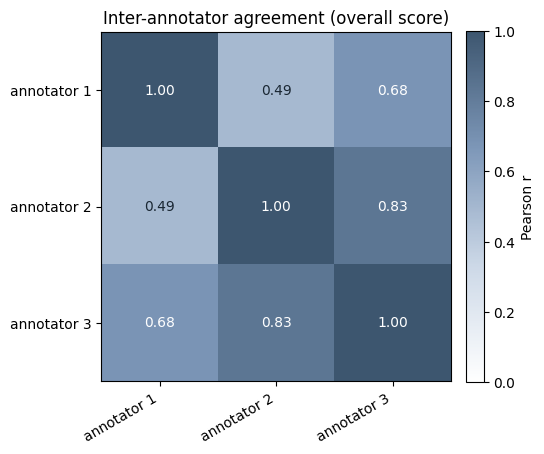

annotator          annotator 1  annotator 2  annotator 3   std
source      trial                                             
apertus     281          85.00        52.69        59.62 17.01
gpt5_nano   203          83.67        59.00        73.00 12.37
            42           89.50        69.00        72.00 11.07
            233          87.50        69.44        74.44  9.32
data_points 191          86.36        68.64        79.09  8.91
apertus     295          55.83        60.00        70.00  7.28
data_points 254          82.89        68.68        73.42  7.24
phi4_mini   20           57.00        45.00        52.00  6.03
apertus     249          55.00        43.57        49.29  5.71
data_points 204          78.33        68.89        77.22  5.16

In [16]:
from matplotlib.colors import LinearSegmentedColormap

pivot = trials_df.pivot_table(index=["source", "trial"], columns="annotator", values="overall")
corr = pivot.corr()
print("Pairwise correlation of 'overall' score across annotators:")
display(corr)

spread = pivot.std(axis=1).rename("std_across_annotators")
print(f"Mean per-trial std across annotators: {spread.mean():.1f} points")

# Sequential colormap anchored on the requested tone #CCD8E7 (a light blue-grey),
# ramping from white (weak agreement) through that tone to a darker shade (strong).
cmap = LinearSegmentedColormap.from_list(
    "ccd8e7", ["#ffffff", "#CCD8E7", "#7d97b8", "#3d566f"]
)

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr.values, cmap=cmap, vmin=0, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=30, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v > 0.6 else "#1a2733", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
ax.set_title("Inter-annotator agreement (overall score)")
plt.tight_layout()
plt.show()

# Trials with the largest disagreement, for reference.
pivot.assign(std=spread).sort_values("std", ascending=False).head(10)

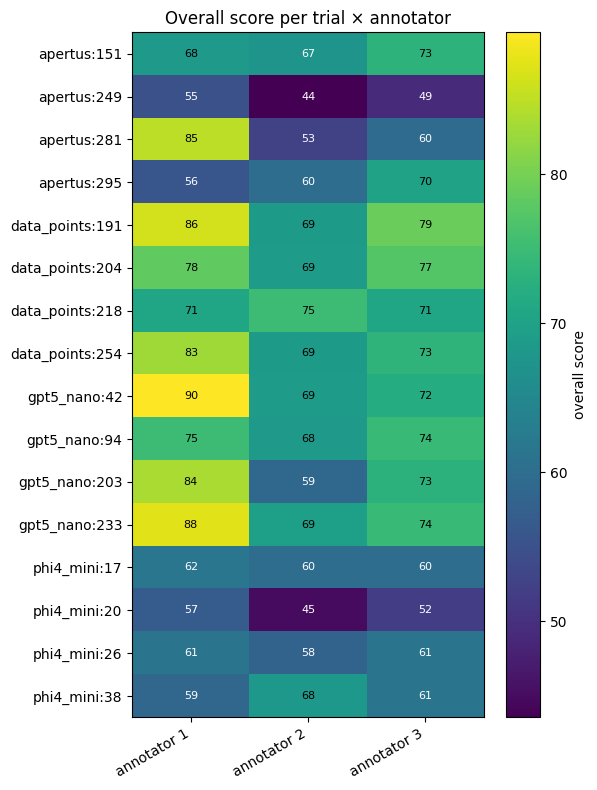

In [17]:
# Heatmap-style view of each annotator's overall score per trial.
p = pivot.copy()
p.index = [f"{s}:{t}" for s, t in p.index]
fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(p.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(p.columns)))
ax.set_xticklabels(p.columns, rotation=30, ha="right")
ax.set_yticks(range(len(p.index)))
ax.set_yticklabels(p.index)
for i in range(p.shape[0]):
    for j in range(p.shape[1]):
        v = p.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                    color="white" if v < p.values[~np.isnan(p.values)].mean() else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="overall score")
ax.set_title("Overall score per trial × annotator")
plt.tight_layout()
plt.show()

## 7. Moderation step

After scoring, annotators could (optionally) build a **moderated taxonomy** by placing data points into topics. Here we summarise how far each annotator got.

In [18]:
def count_tree(node):
    """Recursively count topics and placed data points in a moderated-taxonomy tree."""
    n_topics = 0
    n_points = len(node.get("data_points", []) or [])
    children = node.get("children", []) or []
    for ch in children:
        if isinstance(ch, dict):
            n_topics += 1
            ct, cp = count_tree(ch)
            n_topics += ct
            n_points += cp
    return n_topics, n_points


mod_rows = []
for adir in ANNOTATOR_DIRS:
    mt_path = adir / "moderated_taxonomy.json"
    pk_path = adir / "placed_keys.json"
    if not mt_path.exists():
        mod_rows.append({"annotator": adir.name, "completed_moderation": False,
                         "n_topics": 0, "n_placed_points": 0, "n_placed_keys": 0})
        continue
    tree = load_json(mt_path)
    n_topics, n_points = count_tree(tree)
    n_keys = len(load_json(pk_path)) if pk_path.exists() else None
    mod_rows.append({
        "annotator": adir.name,
        "completed_moderation": True,
        "root_topic": tree.get("topic_name"),
        "n_topics": n_topics,
        "n_placed_points": n_points,
        "n_placed_keys": n_keys,
    })

pd.DataFrame(mod_rows)

,annotator,completed_moderation,root_topic,n_topics,n_placed_points,n_placed_keys
0,annotator 1,True,Digital passport taxonomy,201,1829,1827
1,annotator 2,True,Digital passport taxonomy,1,31,31
2,annotator 3,False,NaN,0,0,0


## 8. Key takeaways

This cell prints a short, auto-generated summary of the headline numbers.

In [19]:
print("=" * 60)
print("ANNOTATOR RESULTS — SUMMARY")
print("=" * 60)
print(f"Annotators            : {len(ANNOTATOR_DIRS)} ({', '.join(p.name for p in ANNOTATOR_DIRS)})")
print(f"Trials evaluated      : {trials_df['trial'].nunique()} (each rated by all annotators)")
print(f"Total topic ratings   : {len(topics_df):,}")
print(f"Mean eval time        : {meta_df['eval_minutes'].mean():.0f} min")
print()
best = trial_summary.iloc[0]
print(f"Top trial (overall)   : {best['source']}:{best['trial']} "
      f"({best['source_label']}) — {best['overall_mean']:.1f}/100")
print("\nBest source by mean overall:")
for _, r in source_summary.iterrows():
    print(f"  {str(r['source_label'] or r['source']):28s} {r['overall_mean']:5.1f}/100  "
          f"(cohesion {r['cohesion_mean']:.0f}, fit {r['fit_mean']:.1f})")
print(f"\nMean inter-annotator spread (overall): {pivot.std(axis=1).mean():.1f} points")

ANNOTATOR RESULTS — SUMMARY
Annotators            : 3 (annotator 1, annotator 2, annotator 3)
Trials evaluated      : 16 (each rated by all annotators)
Total topic ratings   : 861
Mean eval time        : 168 min

Top trial (overall)   : data_points:191 (data point names) — 78.0/100

Best source by mean overall:
  data point names              75.0/100  (cohesion 67, fit 4.1)
  GPT5-nano                     74.6/100  (cohesion 63, fit 4.3)
  Apertus-8B-Instruct           61.7/100  (cohesion 59, fit 3.2)
  Phi-4-mini                    58.7/100  (cohesion 48, fit 3.5)

Mean inter-annotator spread (overall): 6.7 points
